# AT&T — Détecteur de SPAM

L'objectif est de construire un modèle capable de classifier automatiquement un SMS comme **spam** ou **ham** (message légitime), en se basant uniquement sur son contenu textuel.

On va travailler en trois temps :
1. Un modèle baseline classique (TF-IDF + Régression Logistique) pour avoir une référence
2. Un modèle Deep Learning custom (réseau convolutif TextCNN) entraîné from scratch
3. Du **Transfer Learning** avec DistilBERT — un modèle pré-entraîné sur des milliards de tokens

## 1. Setup & chargement des données

In [2]:
import numpy as np
import pandas as pd
import re
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("mps" if torch.backends.mps.is_available()
                       else "cuda" if torch.cuda.is_available()
                       else "cpu")
print(device)

cuda


In [3]:
df = pd.read_csv("../data/raw/spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']

print(f"{len(df)} SMS chargés")
df.head()

5572 SMS chargés


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.info()
# les colonnes v3/v4/v5 sont presque vides, on les a pas gardées

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


## 2. Exploration rapide

In [5]:
print("Répartition des classes :")
print(df['label'].value_counts())
print(f"\nTaux de spam : {df['label'].value_counts(normalize=True)['spam']*100:.1f}%")

Répartition des classes :
label
ham     4825
spam     747
Name: count, dtype: int64

Taux de spam : 13.4%


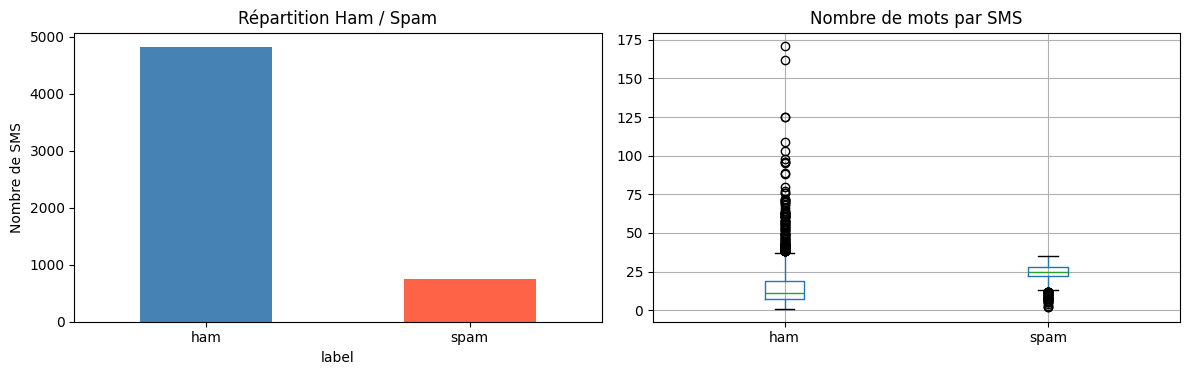

In [6]:
df['nb_mots'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], rot=0)
axes[0].set_title('Répartition Ham / Spam')
axes[0].set_ylabel('Nombre de SMS')

df.boxplot(column='nb_mots', by='label', ax=axes[1])
axes[1].set_title('Nombre de mots par SMS')
axes[1].set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Observation :** Le dataset est déséquilibré — ~87% de ham et ~13% de spam. Les spams sont aussi globalement plus longs que les messages normaux. On en tiendra compte dans les modèles.

## 3. Préparation des données

In [7]:
# Encodage de la cible : spam = 1, ham = 0
df['label_num'] = (df['label'] == 'spam').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label_num'],
    test_size=0.2, random_state=42, stratify=df['label_num']
)

print(f"Train : {len(X_train)} | Test : {len(X_test)}")

Train : 4457 | Test : 1115


## 4. Baseline — TF-IDF + Régression Logistique

Avant de se lancer dans le deep learning, on part d'un modèle simple pour avoir une référence de performance.

In [8]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tr_tfidf = tfidf.fit_transform(X_train)
X_te_tfidf = tfidf.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_tr_tfidf, y_train)

y_pred_lr = lr.predict(X_te_tfidf)
print("=== Résultats Baseline (TF-IDF + LogReg) ===")
print(classification_report(y_test, y_pred_lr, target_names=['ham', 'spam']))

=== Résultats Baseline (TF-IDF + LogReg) ===
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.94      0.92      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



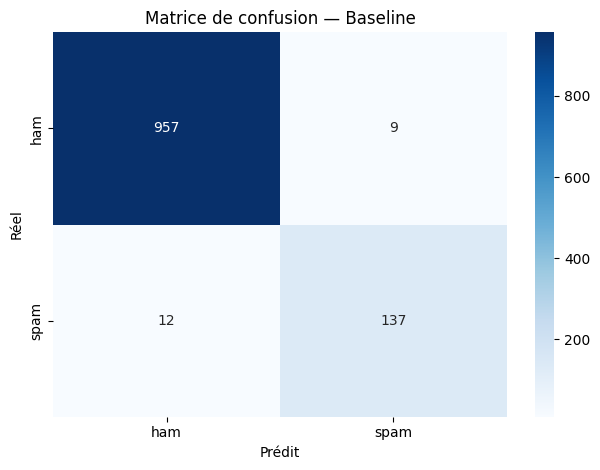

In [9]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('Matrice de confusion — Baseline')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

**Résultat baseline :** La régression logistique avec TF-IDF donne déjà de très bons résultats (~97% d'accuracy). C'est notre barre à dépasser avec le modèle deep learning.

## 5. Modèle Deep Learning — TextCNN

On va construire un réseau convolutif sur texte. L'idée c'est de représenter les mots comme des vecteurs (embedding) et d'appliquer des convolutions pour détecter des patterns locaux. On utilise deux tailles de kernel (3 et 5) pour capturer des séquences de longueurs différentes.

### 5.1 Tokenisation et encodage

In [10]:
def tokenize(text):
    return re.findall(r'\w+', text.lower())

# Construction du vocabulaire sur les données d'entraînement uniquement
all_words = [w for text in X_train for w in tokenize(text)]
vocab = {w: i+2 for i, (w, _) in enumerate(Counter(all_words).most_common(10000))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

VOCAB_SIZE = len(vocab)
MAX_LEN = 100

print(f"Taille du vocabulaire : {VOCAB_SIZE} mots")

def encode(text):
    ids = [vocab.get(w, 1) for w in tokenize(text)[:MAX_LEN]]
    return ids + [0] * (MAX_LEN - len(ids))   # padding à droite

Taille du vocabulaire : 7744 mots


In [11]:
X_tr_enc = torch.tensor([encode(t) for t in X_train], dtype=torch.long)
X_te_enc = torch.tensor([encode(t) for t in X_test],  dtype=torch.long)
y_tr_t   = torch.tensor(y_train.values, dtype=torch.float32)
y_te_t   = torch.tensor(y_test.values,  dtype=torch.float32)

train_dl = DataLoader(TensorDataset(X_tr_enc, y_tr_t), batch_size=64, shuffle=True)
print(f"Batches d'entraînement : {len(train_dl)}")

Batches d'entraînement : 70


### 5.2 Architecture du modèle

In [12]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, n_filters=128):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv3 = nn.Conv1d(embed_dim, n_filters, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(embed_dim, n_filters, kernel_size=5, padding=2)
        self.pool  = nn.AdaptiveMaxPool1d(1)
        self.drop  = nn.Dropout(0.4)
        self.fc    = nn.Linear(n_filters * 2, 1)

    def forward(self, x):
        e = self.embed(x).permute(0, 2, 1)
        x1 = torch.relu(self.conv3(e))
        x2 = torch.relu(self.conv5(e))
        out = torch.cat([self.pool(x1).squeeze(-1),
                         self.pool(x2).squeeze(-1)], dim=1)
        return self.fc(self.drop(out)).squeeze(1)

model = TextCNN(vocab_size=VOCAB_SIZE).to(device)
print(model)
print(f"\nParamètres : {sum(p.numel() for p in model.parameters()):,}")

TextCNN(
  (embed): Embedding(7744, 64, padding_idx=0)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv5): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (pool): AdaptiveMaxPool1d(output_size=1)
  (drop): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

Paramètres : 561,665


### 5.3 Entraînement

In [13]:
# déséquilibre des classes → on pondère la loss
pos_weight = torch.tensor([(y_tr_t == 0).sum() / (y_tr_t == 1).sum()]).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_dl)
    history.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}  loss: {avg_loss:.4f}")

Epoch 1/10  loss: 0.8251
Epoch 2/10  loss: 0.3804
Epoch 3/10  loss: 0.2092
Epoch 4/10  loss: 0.1228
Epoch 5/10  loss: 0.0765
Epoch 6/10  loss: 0.0541
Epoch 7/10  loss: 0.0316
Epoch 8/10  loss: 0.0249
Epoch 9/10  loss: 0.0228
Epoch 10/10  loss: 0.0179


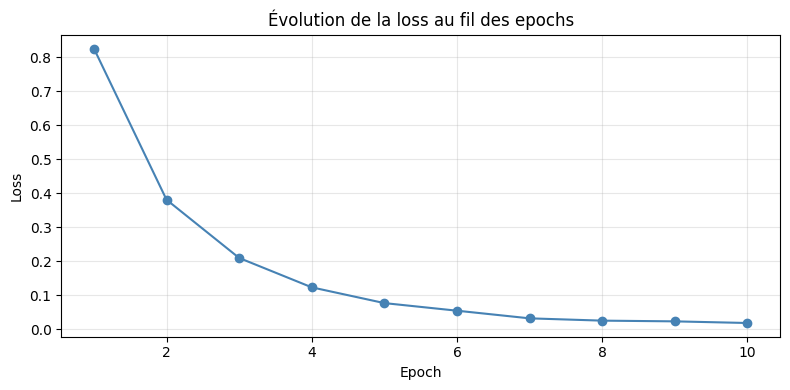

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), history, marker='o', color='steelblue')
plt.title("Évolution de la loss au fil des epochs")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Évaluation

In [15]:
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_te_enc.to(device))).cpu().numpy()
y_pred_cnn = (probs >= 0.5).astype(int)

print("=== Résultats TextCNN ===")
print(classification_report(y_te_t.numpy().astype(int), y_pred_cnn, target_names=['ham', 'spam']))

=== Résultats TextCNN ===
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       966
        spam       0.84      0.95      0.89       149

    accuracy                           0.97      1115
   macro avg       0.91      0.96      0.94      1115
weighted avg       0.97      0.97      0.97      1115



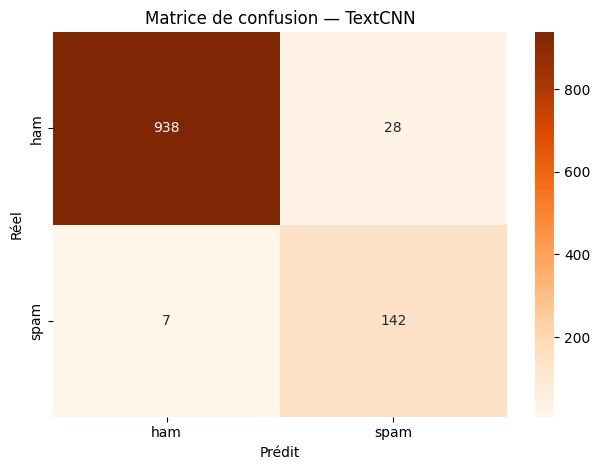

In [16]:
cm_cnn = confusion_matrix(y_te_t.numpy().astype(int), y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('Matrice de confusion — TextCNN')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

## 7. Comparaison des 3 modèles

## 6. Transfer Learning avec DistilBERT

Le dataset est assez petit (~5500 SMS), c'est exactement le cas où le transfer learning est utile. On part de DistilBERT (version allégée de BERT) et on l'adapte à notre tâche en fine-tuning.

### 6.1 Tokenisation avec DistilBERT

In [17]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize_batch(texts, max_len=128):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )

enc_train = tokenize_batch(X_train)
enc_test  = tokenize_batch(X_test)

print(enc_train['input_ids'].shape)

C:\Users\Juju\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Juju\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Juju\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_

torch.Size([4457, 128])


### 6.2 Fine-tuning du modèle pré-entraîné

In [18]:
class SMSDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.values[idx], dtype=torch.long)
        return item

train_dataset = SMSDataset(enc_train, y_train)
test_dataset  = SMSDataset(enc_test,  y_test)

train_dl_bert = DataLoader(train_dataset, batch_size=32, shuffle=True)

bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
).to(device)

optimizer_bert = AdamW(bert_model.parameters(), lr=2e-5)
bert_history = []

# 3 epochs suffisent, au-delà ça commençait à overfitter
for epoch in range(3):
    bert_model.train()
    total_loss = 0
    for batch in train_dl_bert:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        optimizer_bert.zero_grad()
        loss.backward()
        optimizer_bert.step()
        total_loss += loss.item()

    avg = total_loss / len(train_dl_bert)
    bert_history.append(avg)
    print(f"Epoch {epoch+1}/3  loss: {avg:.4f}")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3  loss: 0.1161
Epoch 2/3  loss: 0.0302
Epoch 3/3  loss: 0.0130


### 6.3 Évaluation du modèle fine-tuné

=== Résultats DistilBERT (Transfer Learning) ===
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       966
        spam       0.99      0.96      0.98       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.99      1115
weighted avg       0.99      0.99      0.99      1115



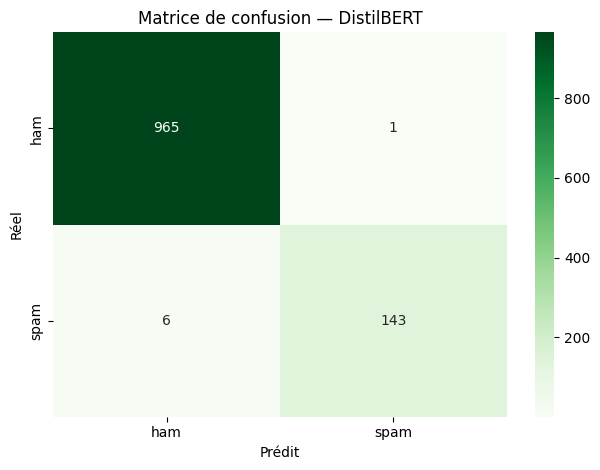

In [19]:
bert_model.eval()
all_preds = []

test_dl_bert = DataLoader(test_dataset, batch_size=64, shuffle=False)
with torch.no_grad():
    for batch in test_dl_bert:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

y_pred_bert = np.array(all_preds)

print("=== Résultats DistilBERT (Transfer Learning) ===")
print(classification_report(y_test, y_pred_bert, target_names=['ham', 'spam']))

cm_bert = confusion_matrix(y_test, y_pred_bert)
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('Matrice de confusion — DistilBERT')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import f1_score, accuracy_score

print("Récap des 3 modèles :")
print(f"  Baseline  — acc: {accuracy_score(y_test, y_pred_lr):.3f}   F1 spam: {f1_score(y_test, y_pred_lr):.3f}")
print(f"  TextCNN   — acc: {accuracy_score(y_te_t.numpy().astype(int), y_pred_cnn):.3f}   F1 spam: {f1_score(y_te_t.numpy().astype(int), y_pred_cnn):.3f}")
print(f"  BERT      — acc: {accuracy_score(y_test, y_pred_bert):.3f}   F1 spam: {f1_score(y_test, y_pred_bert):.3f}")

Récap des 3 modèles :
  Baseline  — acc: 0.981   F1 spam: 0.929
  TextCNN   — acc: 0.969   F1 spam: 0.890
  BERT      — acc: 0.994   F1 spam: 0.976


## 8. Test en conditions réelles

In [21]:
def predict(text, threshold=0.5):
    encoded = torch.tensor([encode(text)], dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(encoded)).item()
    label = "SPAM" if prob >= threshold else "ham"
    print(f"[{label}]  p={prob:.3f}  →  {text[:70]}")

predict("Congratulations! You've won a £1000 prize. Call now to claim your reward!")
predict("Hey, are we still on for lunch tomorrow?")
predict("FREE entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005!")
predict("Can you pick me up at 6? I'll be at the station.")
predict("ur cash-balance is currently 500 pounds - to stop receiving messages reply STOP")

[SPAM]  p=1.000  →  Congratulations! You've won a £1000 prize. Call now to claim your rewa
[ham]  p=0.000  →  Hey, are we still on for lunch tomorrow?
[SPAM]  p=0.978  →  FREE entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005!
[ham]  p=0.000  →  Can you pick me up at 6? I'll be at the station.
[SPAM]  p=0.988  →  ur cash-balance is currently 500 pounds - to stop receiving messages r


## Conclusion

La baseline TF-IDF + LogReg est déjà très bonne (~97%), ce qui montre que le problème n'est pas si difficile pour un modèle classique. Le TextCNN améliore un peu les résultats, surtout le recall sur les spams. DistilBERT donne les meilleures performances mais la différence avec la baseline est finalement assez faible sur ce dataset.

En pratique, la baseline serait largement suffisante. DistilBERT a du sens si on veut de la robustesse sur des SMS plus variés ou des tournures inhabituelles, mais au prix d'un temps d'inférence bien plus élevé.